In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import os

In [3]:
DIR = "./"
DIR_emb = f"{DIR}/Embeddings/MPnet"
DIR_paper = f"{DIR}/DataCollection"

In [4]:
# Years to analyze
years = list(range(1980, 2026))
print(years)
print(len(years))

# Number of papers to keep per year
# N = 100000 # Actual number uesd for the final project.
N = 5000  # Set a small number for example.

[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
46


# Since I used smaller set of papepr, the results shold be (slightly) `different from the final project`.

# Read Embeddings

In [5]:
selection_idx = {}
embeddings = []
for year in years:
    print(f"Processing year: {year}")
    path = os.path.join(DIR_emb, f"MPnet_embeddings_{year}.npy")
    if os.path.exists(path):
        emb = np.load(path)
        # Randomly select N papers if there are more than N
        if len(emb) > N:
            print(f"- Selecting {N} papers randomly.")
            selection_idx[year] = np.random.choice(len(emb), N, replace=False)
            emb = emb[selection_idx[year]]
        else:
            selection_idx[year] = np.arange(len(emb))
            print(f"- Using all {len(emb)} papers.")
            print("")

        embeddings.append(emb)
    else:
        print(f"File not found: {path}")

Processing year: 1980
- Selecting 5000 papers randomly.
Processing year: 1981
- Selecting 5000 papers randomly.
Processing year: 1982
- Selecting 5000 papers randomly.
Processing year: 1983
- Selecting 5000 papers randomly.
Processing year: 1984
- Selecting 5000 papers randomly.
Processing year: 1985
- Selecting 5000 papers randomly.
Processing year: 1986
- Selecting 5000 papers randomly.
Processing year: 1987
- Selecting 5000 papers randomly.
Processing year: 1988
- Selecting 5000 papers randomly.
Processing year: 1989
- Selecting 5000 papers randomly.
Processing year: 1990
- Selecting 5000 papers randomly.
Processing year: 1991
- Selecting 5000 papers randomly.
Processing year: 1992
- Selecting 5000 papers randomly.
Processing year: 1993
- Selecting 5000 papers randomly.
Processing year: 1994
- Selecting 5000 papers randomly.
Processing year: 1995
- Selecting 5000 papers randomly.
Processing year: 1996
- Selecting 5000 papers randomly.
Processing year: 1997
- Selecting 5000 papers ra

In [6]:
# concat all embeddings
embeddings = np.concatenate(embeddings, axis=0)
year_info = []
for year in years:
    year_info.extend([year] * len(selection_idx[year]))
year_info = np.array(year_info)
embeddings = np.hstack((year_info.reshape(-1, 1), embeddings))
print(f"Total embeddings shape: {embeddings.shape}")

Total embeddings shape: (230000, 769)


In [7]:
df_input = pd.DataFrame(
    {"year": embeddings[:, 0].astype(int), "embedding_feature": list(embeddings[:, 1:])}
)
df_input.head()

,year,embedding_feature
0,1980,"[-0.027169644832611084, -0.035451073199510574,..."
1,1980,"[0.026341648772358894, -0.005720170680433512, ..."
2,1980,"[0.0013593875337392092, -0.014034304767847061,..."
3,1980,"[0.006833089981228113, -0.01941448636353016, -..."
4,1980,"[0.020523570477962494, -0.022163912653923035, ..."


In [8]:
# save dictionary of selection_idx
np.save(f"{DIR}/selection_idx_part23.npy", selection_idx)

# load dic
load_dic = np.load(f"{DIR}/selection_idx_part23.npy", allow_pickle=True).item()

# Read Embeddings (In case you are using pre-selected paper index)

embeddings = []
for year in years:
    print(f"Processing year: {year}")
    path = os.path.join(DIR_emb, f"MPnet_embeddings_{year}.npy")
    if os.path.exists(path):
        emb = np.load(path)
        # select only the papers that were selected previously
        emb = emb[load_dic[year]]
        embeddings.append(emb)

    else:
        print(f"File not found: {path}")


# concat all embeddings
embeddings = np.concatenate(embeddings, axis=0)
year_info = []
for year in years:
    year_info.extend([year] * len(load_dic[year]))
year_info = np.array(year_info)
embeddings = np.hstack((year_info.reshape(-1, 1), embeddings))

print(f"Total embeddings shape: {embeddings.shape}")


df_input = pd.DataFrame(
    {
        "year": embeddings[:, 0].astype(int),
        "embedding_feature": list(embeddings[:, 1:]),
    }
)
df_input.head()

# Read paper information

In [9]:
df_paper = []
for year in years:
    print(year)
    path = os.path.join(DIR_paper, f"pubmed_data_{year}.tsv")
    if os.path.exists(path):
        df_year = pd.read_csv(
            path,
            sep="\t",
            usecols=["PMID", "journal", "Year", "title", "abstract"],
        )
        # select only the papers that were selected for embeddings
        df_year = df_year.iloc[load_dic[year]]
        df_paper.append(df_year)
    else:
        print(f"File not found: {path}")

df_paper = pd.concat(df_paper, ignore_index=True)
print(f"Total papers: {len(df_paper)}")

1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
Total papers: 230000


# Read ASJC Annotation

In [10]:
df_ASJC = pd.read_csv("./ASJC_Annotation.txt", sep="\t")
df_ASJC.head()

,Title,ASJC_1st,Subject_area_1st
0,PloS one,Multidisciplinary,Multidisciplinary
1,Scientific reports,Multidisciplinary,Multidisciplinary
2,The Journal of biological chemistry,Molecular Biology,Life Sciences
3,Proceedings of the National Academy of Science...,Multidisciplinary,Multidisciplinary
4,International journal of molecular sciences,Inorganic Chemistry,Physical Sciences


In [11]:
print(df_paper.shape)
df_paper_ASJC = df_paper.merge(df_ASJC, left_on="journal", right_on="Title", how="left")
print(df_paper_ASJC.shape)
df_paper_ASJC.head()

(230000, 5)
(230000, 8)


,Year,PMID,title,abstract,journal,Title,ASJC_1st,Subject_area_1st
0,1980,6993073,Hidden anti-nuclear antibodies in rheumatic di...,Hidden anti-nuclear antibodies are demonstrate...,Clinical and experimental immunology,Clinical and experimental immunology,Immunology and Allergy,Health Sciences
1,1980,7410793,Effects of overlearning and incentive on the a...,"Structured Learning Therapy, a skill training ...",Journal of gerontology,NaN,NaN,NaN
2,1980,7226301,[Gastrin: review of current knowledge].,The Authors review recent advances in understa...,Chirurgia italiana,Chirurgia italiana,Surgery,Health Sciences
3,1980,7435759,Myositis ossificans of the upper arm.,Myositis ossificans is a benign condition resu...,The American journal of sports medicine,NaN,NaN,NaN
4,1980,6768767,Characterization of Brucella abortus soluble a...,A soluble antigen extract of Brucella abortus ...,Journal of clinical microbiology,Journal of clinical microbiology,Microbiology (medical),Health Sciences


In [12]:
df_input["PMID"] = df_paper_ASJC.PMID
df_input = df_input.merge(
    df_paper_ASJC,
    on="PMID",
    how="left",
)
df_input["text"] = df_input.title + " | " + df_input.abstract
df_input.head()

,year,embedding_feature,PMID,Year,title,abstract,journal,Title,ASJC_1st,Subject_area_1st,text
0,1980,"[-0.027169644832611084, -0.035451073199510574,...",6993073,1980,Hidden anti-nuclear antibodies in rheumatic di...,Hidden anti-nuclear antibodies are demonstrate...,Clinical and experimental immunology,Clinical and experimental immunology,Immunology and Allergy,Health Sciences,Hidden anti-nuclear antibodies in rheumatic di...
1,1980,"[0.026341648772358894, -0.005720170680433512, ...",7410793,1980,Effects of overlearning and incentive on the a...,"Structured Learning Therapy, a skill training ...",Journal of gerontology,NaN,NaN,NaN,Effects of overlearning and incentive on the a...
2,1980,"[0.0013593875337392092, -0.014034304767847061,...",7226301,1980,[Gastrin: review of current knowledge].,The Authors review recent advances in understa...,Chirurgia italiana,Chirurgia italiana,Surgery,Health Sciences,[Gastrin: review of current knowledge]. | The ...
3,1980,"[0.006833089981228113, -0.01941448636353016, -...",7435759,1980,Myositis ossificans of the upper arm.,Myositis ossificans is a benign condition resu...,The American journal of sports medicine,NaN,NaN,NaN,Myositis ossificans of the upper arm. | Myosit...
4,1980,"[0.020523570477962494, -0.022163912653923035, ...",6768767,1980,Characterization of Brucella abortus soluble a...,A soluble antigen extract of Brucella abortus ...,Journal of clinical microbiology,Journal of clinical microbiology,Microbiology (medical),Health Sciences,Characterization of Brucella abortus soluble a...


In [13]:
# =========================================================
# 0. helper functions
# =========================================================
def to_5yr_bin(year, start=1980):
    # return ((year - start) // 5) * 5 + start
    # For example, 1980-1984 -> "1980-1984", 1985-1989 -> "1985-1989", etc.
    start_year = ((year - start) // 5) * 5 + start
    end_year = start_year + 4
    return f"{start_year}-{end_year}"


def stack_embeddings(df, emb_col="embedding_feature"):
    """df[emb_col] -> (N, D) matrix"""
    return np.vstack(df[emb_col].values)


def regularize_cov(cov, eps=1e-6):
    """Make covariance matrix positive semi-definite"""
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals[eigvals < eps] = eps
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def compute_group_stats(df_proj, group_col="year_bin"):
    """
    Input columns needed: group_col, PC1, PC2
    Output: centroid and covariance summary per group
    """
    rows = []

    for g, sub in df_proj.groupby(group_col):
        coords = sub[["PC1", "PC2"]].values
        centroid = coords.mean(axis=0)
        cov = np.cov(coords.T)
        cov = regularize_cov(cov)

        rows.append(
            {
                group_col: g,
                "centroid_PC1": centroid[0],
                "centroid_PC2": centroid[1],
                "var_PC1": cov[0, 0],
                "var_PC2": cov[1, 1],
                "cov_PC1_PC2": cov[0, 1],
                "n_papers": len(sub),
            }
        )

    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


def plot_cov_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Draw covariance ellipse"""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(
        xy=mean, width=width, height=height, angle=angle, fill=False, **kwargs
    )
    ax.add_patch(ellipse)

In [14]:
# =========================================================
# 1. train / test split
# =========================================================

# Keep Cancer-papers only
# by searching cancer-related terms in title and abstract.
cancer_regex = (
    r"\b(?:"
    r"cancers?|"
    r"tumou?rs?|"
    r"neoplasms?|"
    r"malignan(?:t|cy|cies)?|"
    r"oncolog(?:y|ic|ist|ists)?|"
    r"oncogen(?:ic|e|es)?|"
    r"carcinomas?|"
    r"metasta(?:sis|tic|size|sized|sizes|zing)?|"
    r"tumorigen(?:es|ic|esis)?"
    r")\b"
)

df = df_input.copy()
df["is_cancer"] = df["text"].str.contains(cancer_regex, case=False, na=False)

print(f"Before filtering for cancer-related papers: {len(df)}")
df = df.loc[df.is_cancer, :]
print(f"After filtering for cancer-related papers: {len(df)}")

Before filtering for cancer-related papers: 230000
After filtering for cancer-related papers: 29465


In [15]:
train_df = df[(df["year"] >= 1980) & (df["year"] <= 2019)].copy()
train_df.reset_index(inplace=True, drop=True)

test_df = df[(df["year"] >= 2020) & (df["year"] <= 2024)].copy()  # five year test set
test_df.reset_index(inplace=True, drop=True)

print("Train papers (1980-2019):", len(train_df))
print("Test papers (2020-2024):", len(test_df))

Train papers (1980-2019): 24860
Test papers (2020-2024): 3829


In [16]:
# =========================================================
# 2. PCA fit on TRAIN only
# =========================================================
X_train = stack_embeddings(train_df, emb_col="embedding_feature")
X_test = stack_embeddings(test_df, emb_col="embedding_feature")
print(X_train.shape, X_test.shape)

n_PC = 10
pca = PCA(n_components=n_PC, random_state=42)

train_pca = pca.fit_transform(X_train)  # fit only on train
test_pca = pca.transform(X_test)  # transform test using same PCA

train_proj = train_df[["PMID", "year", "ASJC_1st", "text"]].copy()
for pc in range(n_PC):
    train_proj[f"PC{pc+1}"] = train_pca[:, pc]
print(train_proj.head().to_markdown())

test_proj = test_df[["PMID", "year", "ASJC_1st", "text"]].copy()
for pc in range(n_PC):
    test_proj[f"PC{pc+1}"] = test_pca[:, pc]
print(test_proj.head().to_markdown())

(24860, 768) (3829, 768)
|    |    PMID |   year | ASJC_1st        | text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [17]:
# =========================================================
# 3. make 5-year bins on training data
# =========================================================
train_proj["year_bin"] = train_proj["year"].apply(to_5yr_bin)
test_proj["year_bin"] = test_proj["year"].apply(to_5yr_bin)

train_summary = compute_group_stats(train_proj, group_col="year_bin")
test_summary = compute_group_stats(test_proj, group_col="year_bin")
print(train_summary.to_markdown())
print(test_summary.to_markdown())

|    | year_bin   |   centroid_PC1 |   centroid_PC2 |   var_PC1 |   var_PC2 |   cov_PC1_PC2 |   n_papers |
|---:|:-----------|---------------:|---------------:|----------:|----------:|--------------:|-----------:|
|  0 | 1980-1984  |     0.0644007  |     0.072077   | 0.0485232 | 0.0289789 |  -0.000424091 |       2395 |
|  1 | 1985-1989  |     0.0543948  |     0.0555441  | 0.0514159 | 0.0319483 |  -0.000693171 |       2679 |
|  2 | 1990-1994  |     0.0305361  |     0.0378339  | 0.0538703 | 0.0311168 |  -0.0023571   |       2802 |
|  3 | 1995-1999  |    -0.00155913 |     0.0274765  | 0.0556862 | 0.0322048 |  -0.00150615  |       3101 |
|  4 | 2000-2004  |    -0.0222366  |     0.00385781 | 0.0543236 | 0.0306118 |  -0.00109569  |       3323 |
|  5 | 2005-2009  |    -0.0205497  |    -0.0302608  | 0.0538408 | 0.0297189 |  -0.00143718  |       3263 |
|  6 | 2010-2014  |    -0.0324292  |    -0.0468296  | 0.0515123 | 0.027929  |  -0.00073618  |       3600 |
|  7 | 2015-2019  |    -0.0332701  | 

# PCA Plot

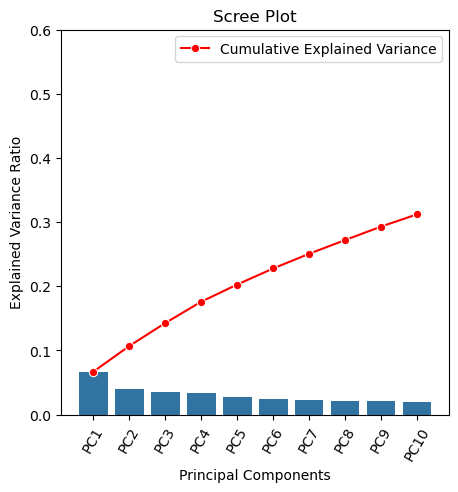

In [18]:
# scree plot
explained_variance = pca.explained_variance_ratio_

# barplot
plt.figure(figsize=(5, 5))
sns.barplot(
    x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance
)
# add cumulative explained variance line
cumulative_explained_variance = np.cumsum(explained_variance)
sns.lineplot(
    x=[f"PC{i+1}" for i in range(len(explained_variance))],
    y=cumulative_explained_variance,
    marker="o",
    color="red",
    label="Cumulative Explained Variance",
)
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.ylim(0, 0.6)
# retate x labels
plt.xticks(rotation=60)

# save image
plt.savefig("./figures/Fig2_tmp_pca.png", dpi=150, bbox_inches="tight")

/tmp/ipykernel_1284739/138358760.py:5: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_1284739/138358760.py:21: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(


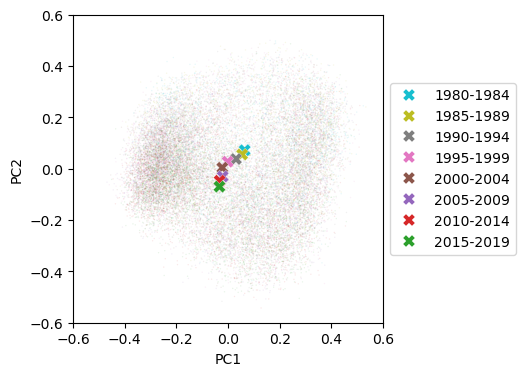

In [19]:
plt.figure(figsize=(4, 4))


# 2D Scatter
sns.scatterplot(
    data=train_proj,
    x="PC1",
    y="PC2",
    hue="year_bin",
    s=1,
    alpha=0.1,
    legend=False,
    linewidth=0,
    palette=sns.color_palette("tab10")[::-1],
)
plt.title("PCA of Cancer-paper Abstracts (1980-2019)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

# plot Centroid of each year (Mean)
sns.scatterplot(
    data=train_summary,
    x="centroid_PC1",
    y="centroid_PC2",
    hue="year_bin",
    s=80,
    marker="X",
    linewidth=0.2,
    palette=sns.color_palette("tab10")[::-1],
)
# plt.title("Centroid of PCA of Paper Abstracts by Year")
plt.title("")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

# save image
plt.savefig("./figures/Fig2_A.png", dpi=150, bbox_inches="tight")

/tmp/ipykernel_1284739/4257117958.py:3: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_1284739/4257117958.py:18: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(


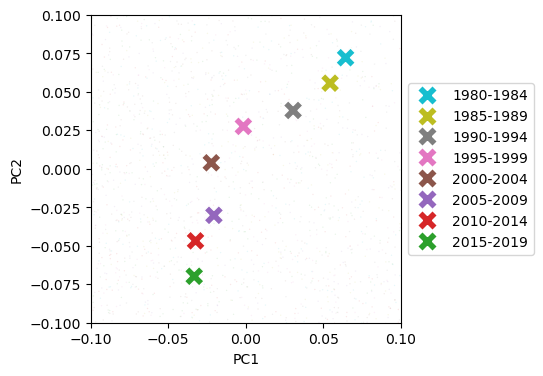

In [20]:
plt.figure(figsize=(4, 4))
# 2D Scatter
sns.scatterplot(
    data=train_proj,
    x="PC1",
    y="PC2",
    hue="year_bin",
    s=1,
    alpha=0.1,
    legend=False,
    palette=sns.color_palette("tab10")[::-1],
)
plt.title("PCA of Cancer-paper Abstracts (1980-2019)")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

# plot Centroid of each year (Mean)
sns.scatterplot(
    data=train_summary,
    x="centroid_PC1",
    y="centroid_PC2",
    hue="year_bin",
    s=200,
    marker="X",
    linewidth=1,
    palette=sns.color_palette("tab10")[::-1],
)
plt.title("")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

# save image
plt.savefig("./figures/Fig2_B.png", dpi=150, bbox_inches="tight")

(-0.6, 0.6)

<Figure size 800x600 with 0 Axes>

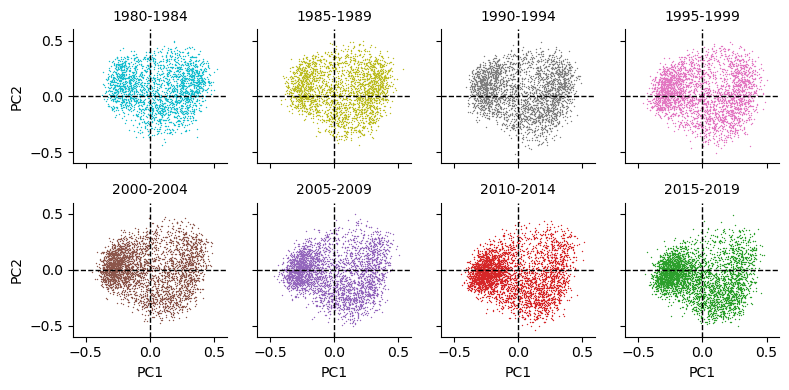

In [21]:
plt.figure(figsize=(8, 6))

# facet by Subject_area_1st.
g = sns.FacetGrid(
    train_proj,
    col="year_bin",
    col_wrap=4,
    height=2,
    hue="year_bin",
    palette=sns.color_palette("tab10")[::-1],
)
g.map_dataframe(sns.scatterplot, x="PC1", y="PC2", s=1, alpha=1, linewidth=0)
# add x,y=0  guide line
for ax in g.axes.flat:
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.axvline(0, color="black", lw=1, ls="--")

g.set_titles(col_template="{col_name}")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

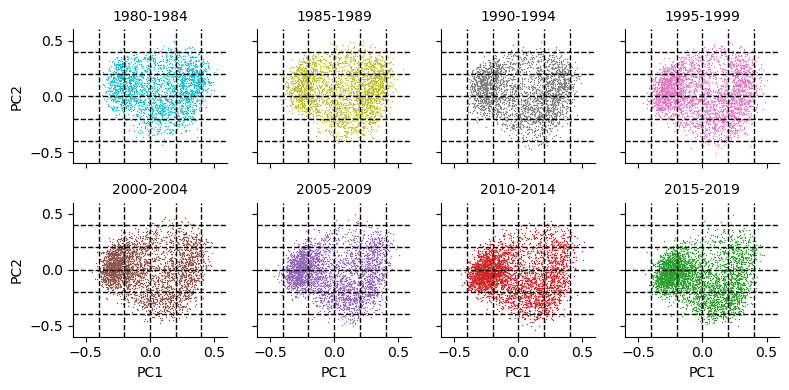

In [22]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    train_proj,
    col="year_bin",
    col_wrap=4,
    height=2,
    hue="year_bin",
    palette=sns.color_palette("tab10")[::-1],
)
g.map_dataframe(sns.scatterplot, x="PC1", y="PC2", s=1, alpha=1, linewidth=0)
# add x,y guide lines
for ax in g.axes.flat:
    for y in [-0.4, -0.2, 0, 0.2, 0.4]:
        ax.axhline(y, color="black", lw=1, ls="--")
    for x in [-0.4, -0.2, 0, 0.2, 0.4]:
        ax.axvline(x, color="black", lw=1, ls="--")

g.set_titles(col_template="{col_name}")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.show()

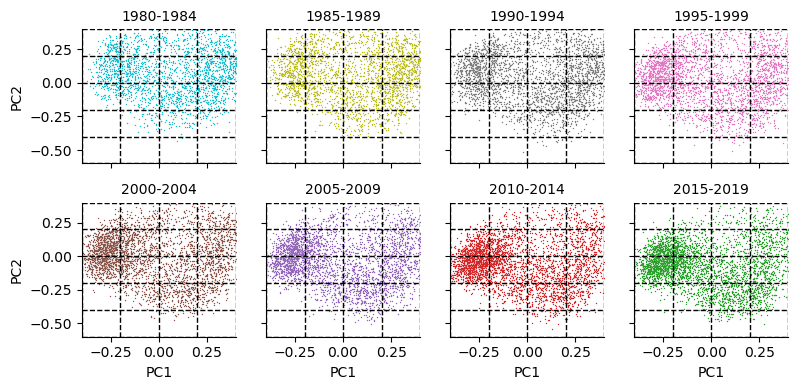

In [23]:
# Selected 20 Grids!

# facet by Subject_area_1st.
g = sns.FacetGrid(
    train_proj,
    col="year_bin",
    col_wrap=4,
    height=2,
    hue="year_bin",
    palette=sns.color_palette("tab10")[::-1],
)
g.map_dataframe(sns.scatterplot, x="PC1", y="PC2", s=1, alpha=1, linewidth=0)
# add x,y guide lines
for ax in g.axes.flat:
    for y in [-0.6, -0.4, -0.2, 0, 0.2, 0.4]:
        ax.axhline(y, color="black", lw=1, ls="--")
    for x in [-0.4, -0.2, 0, 0.2, 0.4]:
        ax.axvline(x, color="black", lw=1, ls="--")

g.set_titles(col_template="{col_name}")
plt.xlim(-0.4, 0.4)
plt.ylim(-0.6, 0.4)

# save image
plt.savefig("./figures/Fig2_C.png", dpi=150, bbox_inches="tight")

# Density Analysis

In [24]:
# Density shift analyis

# 1. subset the 2D space into 4x4, 20 grids
train_proj["x_bin"] = pd.cut(
    train_proj["PC1"], bins=[-0.4, -0.2, 0, 0.2, 0.4], labels=["A", "B", "C", "D"]
)
train_proj["y_bin"] = pd.cut(
    train_proj["PC2"],
    bins=[-0.6, -0.4, -0.2, 0, 0.2, 0.4],
    labels=["E", "D", "C", "B", "A"],
)
# Label grid_bin as grid_1-20.
grid_dic = {
    "A_A": "Grid_1",
    "A_B": "Grid_2",
    "A_C": "Grid_3",
    "A_D": "Grid_4",
    "B_A": "Grid_5",
    "B_B": "Grid_6",
    "B_C": "Grid_7",
    "B_D": "Grid_8",
    "C_A": "Grid_9",
    "C_B": "Grid_10",
    "C_C": "Grid_11",
    "C_D": "Grid_12",
    "D_A": "Grid_13",
    "D_B": "Grid_14",
    "D_C": "Grid_15",
    "D_D": "Grid_16",
    "E_A": "Grid_17",
    "E_B": "Grid_18",
    "E_C": "Grid_19",
    "E_D": "Grid_20",
}

train_proj["grid_bin"] = (
    train_proj["y_bin"].astype(str) + "_" + train_proj["x_bin"].astype(str)
)
train_proj["grid_bin"] = train_proj["grid_bin"].map(grid_dic)

grid_order = [f"Grid_{i}" for i in range(1, 21)]
train_proj["grid_bin"] = pd.Categorical(
    train_proj["grid_bin"], categories=grid_order, ordered=True
)

train_proj.head()

,PMID,year,ASJC_1st,text,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,year_bin,x_bin,y_bin,grid_bin
0,7459901,1980,Cancer Research,Phase II trial of vindesine in advanced head a...,-0.046247,-0.149410,-0.148450,-0.102054,0.029306,-0.066471,0.123632,-0.057932,0.194391,-0.003934,1980-1984,B,C,Grid_10
1,6777321,1980,Dentistry,Chondrosarcoma of mandible misdiagnosed as cho...,0.315641,0.302096,-0.020813,0.070254,0.049226,0.062164,0.159457,-0.126212,-0.017556,0.042636,1980-1984,D,A,Grid_4
2,6929868,1980,Surgery,Selective conventional and xero-arteriography ...,0.312177,0.002565,-0.279964,-0.031677,0.149388,0.130290,-0.052357,-0.022434,0.067675,-0.037042,1980-1984,D,B,Grid_8
3,7451111,1980,Bioengineering,Immunoglobulin levels in children with celiac ...,-0.057795,0.069857,-0.079223,0.494709,-0.125163,-0.185595,-0.137252,0.081654,0.082166,-0.153697,1980-1984,B,B,Grid_6
4,7445788,1980,Nephrology,[Our experiences with a standard program in th...,0.317658,0.054599,0.054203,-0.027149,0.043913,0.011383,-0.188061,0.231640,0.083626,0.104511,1980-1984,D,B,Grid_8


In [25]:
train_proj.grid_bin.value_counts()

grid_bin
Grid_5     3097
Grid_9     2998
Grid_6     2176
Grid_8     2143
Grid_10    2135
Grid_12    1874
Grid_11    1845
Grid_15    1498
Grid_7     1153
Grid_4     1149
Grid_2      894
Grid_16     840
Grid_14     763
Grid_3      718
Grid_1      488
Grid_19     185
Grid_13     138
Grid_20      35
Grid_18      28
Grid_17       1
Name: count, dtype: int64

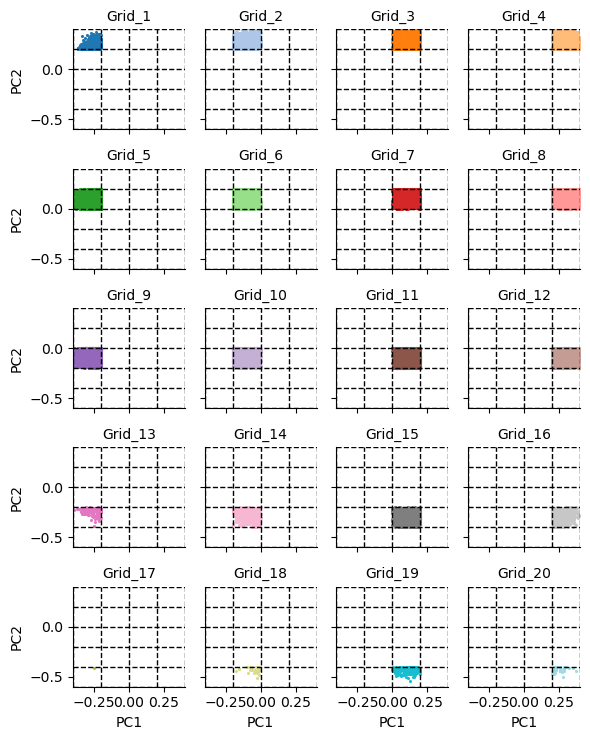

In [28]:
# plt.figure(figsize=(10, 5))
# facet by Subject_area_1st.
g = sns.FacetGrid(
    train_proj, col="grid_bin", col_wrap=4, height=1.5, hue="grid_bin", palette="tab20"
)
g.map_dataframe(sns.scatterplot, x="PC1", y="PC2", s=5, alpha=1, linewidth=0)
# add x,y guide lines
for ax in g.axes.flat:
    for y in [-0.6, -0.4, -0.2, 0, 0.2, 0.4]:
        ax.axhline(y, color="black", lw=1, ls="--")
    for x in [-0.4, -0.2, 0, 0.2, 0.4]:
        ax.axvline(x, color="black", lw=1, ls="--")

g.set_titles(col_template="{col_name}")
plt.xlim(-0.4, 0.4)
plt.ylim(-0.6, 0.4)
plt.show()

In [29]:
# 2. count number of papers in each grid for each year_bin
train_proj_density = (
    train_proj.groupby(["year_bin", "grid_bin"]).size().unstack(fill_value=0)
)
# normalize by number of papers in each year_bin
train_proj_density = train_proj_density.div(train_proj_density.sum(axis=1), axis=0)
train_proj_density = train_proj_density.loc[:, [f"Grid_{i}" for i in range(1, 21)]]
train_proj_density

grid_bin,Grid_1,Grid_2,Grid_3,Grid_4,Grid_5,Grid_6,Grid_7,Grid_8,Grid_9,Grid_10,Grid_11,Grid_12,Grid_13,Grid_14,Grid_15,Grid_16,Grid_17,Grid_18,Grid_19,Grid_20
year_bin,,,,,,,,,,,,,,,,,,,,
1980-1984,0.047452,0.057557,0.050967,0.077768,0.089192,0.110721,0.073814,0.141037,0.038664,0.066784,0.094903,0.082601,0.000000,0.018014,0.032953,0.016696,0.000000,0.000000,0.000879,0.000000
1985-1989,0.038132,0.059144,0.050195,0.071206,0.108949,0.078210,0.067704,0.135409,0.054864,0.073152,0.080934,0.091051,0.000389,0.019066,0.045525,0.025292,0.000000,0.000000,0.000778,0.000000
1990-1994,0.038320,0.059690,0.042373,0.063007,0.131540,0.079219,0.051216,0.111275,0.071481,0.067060,0.093589,0.089536,0.001842,0.020634,0.048268,0.025424,0.000000,0.000368,0.004422,0.000737
1995-1999,0.027081,0.053828,0.031762,0.057506,0.162487,0.083250,0.048144,0.091608,0.094952,0.071214,0.076897,0.082581,0.002675,0.026413,0.051822,0.030425,0.000000,0.000669,0.006018,0.000669
2000-2004,0.015446,0.037380,0.028421,0.043559,0.169293,0.098548,0.045721,0.079395,0.126969,0.083102,0.057152,0.069509,0.005870,0.034600,0.064257,0.033055,0.000000,0.001545,0.005561,0.000618
2005-2009,0.008168,0.023249,0.020735,0.035501,0.140748,0.087025,0.044612,0.070688,0.158027,0.086082,0.067232,0.078856,0.006598,0.039585,0.078542,0.040842,0.000000,0.001885,0.010682,0.000943
2010-2014,0.003673,0.016954,0.017519,0.032212,0.114157,0.091551,0.034190,0.060186,0.193275,0.109918,0.076293,0.067533,0.010172,0.041820,0.072054,0.041537,0.000000,0.001130,0.012433,0.003391
2015-2019,0.002193,0.009046,0.011787,0.021382,0.101700,0.092928,0.032072,0.055647,0.189967,0.128289,0.073465,0.067708,0.013158,0.041667,0.084156,0.052906,0.000274,0.002741,0.015077,0.003838


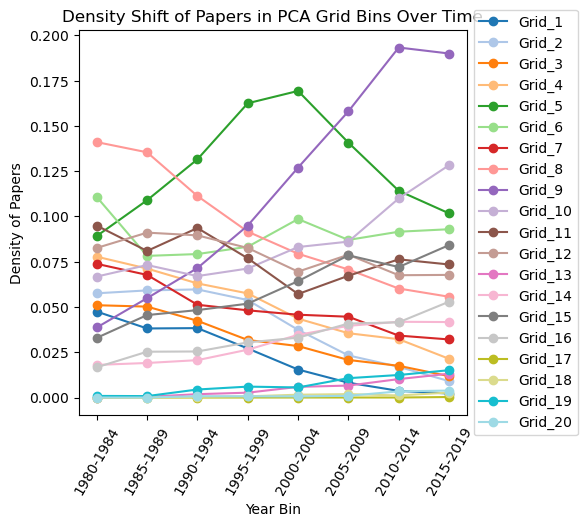

In [30]:
# lineplot
plt.figure(figsize=(5, 5))

n_lines = len(train_proj_density.columns)
colors = plt.cm.tab20(np.linspace(0, 1, n_lines))

for color, grid in zip(colors, train_proj_density.columns):
    plt.plot(
        train_proj_density.index,
        train_proj_density[grid],
        marker="o",
        label=grid,
        color=color,
    )

plt.title("Density Shift of Papers in PCA Grid Bins Over Time")
plt.xlabel("Year Bin")
plt.ylabel("Density of Papers")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=60)
plt.show()

/tmp/ipykernel_1284739/2979631842.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1284739/2979631842.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1284739/2979631842.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1284739/2979631842.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


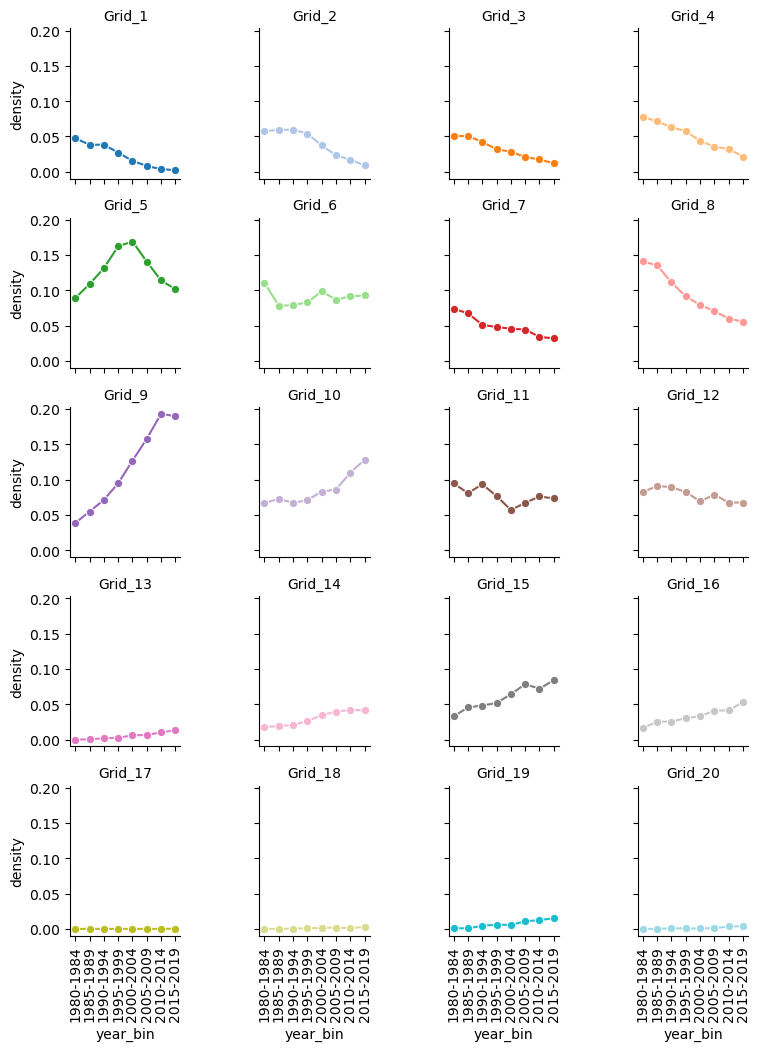

In [32]:
# line plot facet by group (keep same color for each grid_bin)
g = sns.FacetGrid(
    train_proj_density.reset_index().melt(
        id_vars="year_bin", var_name="grid_bin", value_name="density"
    ),
    col="grid_bin",
    col_wrap=4,
    height=2,
    hue="grid_bin",
    palette="tab20",
)
g.map_dataframe(sns.lineplot, x="year_bin", y="density", marker="o")
g.set_titles(col_template="{col_name}")

# rotate x axis at the bottom row
for ax in g.axes[-4:]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# save image
plt.savefig("./figures/Fig3_A.png", dpi=150, bbox_inches="tight")

# Grid to Keyword mapping (using BERTopic)

# Grid 9

In [33]:
# Increasing grid.
target = "Grid_9"
train_proj_target = train_proj.loc[train_proj.grid_bin == target, :]
print(train_proj_target.shape)
train_proj_target.head()

(2998, 18)


,PMID,year,ASJC_1st,text,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,year_bin,x_bin,y_bin,grid_bin
10,7452674,1980,Drug Discovery,2-Methylanthraquinone derivatives as potential...,-0.268198,-0.166959,-0.178776,-0.152598,0.038043,0.111679,0.080084,0.089174,0.173339,0.044494,1980-1984,A,C,Grid_9
31,7190578,1980,NaN,Testosterone-estradiol binding globulin binds ...,-0.219004,-0.029107,0.047262,-0.028756,0.372275,0.207118,-0.187873,0.122824,-0.118972,0.008950,1980-1984,A,C,Grid_9
33,7273277,1980,Cancer Research,"Metabolism of 1,2-dimethylhydrazine by culture...",-0.221227,-0.055699,-0.015936,0.058416,-0.144742,0.289514,-0.152612,0.148545,0.318074,0.016549,1980-1984,A,C,Grid_9
43,7388789,1980,Cancer Research,In vitro effects on DNA synthesis as a predict...,-0.217812,-0.009558,-0.182655,-0.044900,0.027484,-0.192094,-0.270276,0.180794,0.224096,-0.051846,1980-1984,A,C,Grid_9
69,6156458,1980,Multidisciplinary,Methotrexate polyglutamate synthesis by cultur...,-0.296484,-0.111142,-0.116509,-0.168478,0.055449,0.086882,-0.126819,0.129440,0.156444,-0.092885,1980-1984,A,C,Grid_9


In [ ]:
embedding_model = SentenceTransformer("neuml/pubmedbert-base-embeddings")
umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
vectorizer_model = CountVectorizer(stop_words="english")  # 불용어 제거
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    nr_topics="auto",
)

In [37]:
# Fit BERTopic on the target grid's documents
input_docs = train_proj_target.text.tolist()
input_year = train_proj_target.year.tolist()

topics, probs = topic_model.fit_transform(input_docs)

In [38]:
# Topics and Keywords
# Topic -1: Outliers.
topic_info = topic_model.get_topic_info()
print(topic_info.head(10).to_markdown())

|    |   Topic |   Count | Name                                  | Representation                                                                                                 | Representative_Docs                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
# # (OPTIONAL): I don't think it helps interpretability, it rather makes keywords more blurry. --> NOT using this.

# # Reduce outliers using the c-tf-idf strategy
# new_topics = topic_model.reduce_outliers(input_docs, topics, strategy="c-tf-idf")
# topic_model.update_topics(
#     input_docs, topics=new_topics, vectorizer_model=vectorizer_model
# )

In [40]:
# Keyword bar chart
fig_words = topic_model.visualize_barchart(
    top_n_topics=8, n_words=10, height=300, title="Grid 9: Key Topic Words"
)
fig_words.show()

In [42]:
# Time-based topic analysis
topics_over_time = topic_model.topics_over_time(input_docs, input_year)
topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=8,
    normalize_frequency=True,
    width=800,
    height=400,
    title="Grid 9: Keywords over Time",
)

# Future Prediction

In [43]:
# =========================================================
# 4. fit trend models for centroid
# =========================================================
train_summary["x_bin_label"] = train_summary["year_bin"]
train_summary["x_bin"] = train_summary["year_bin"].apply(lambda x: int(x.split("-")[0]))

x_bin = train_summary["x_bin"].values.reshape(-1, 1)

# Polynomial
poly_degree = 2
model_pc1 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, train_summary["centroid_PC1"])
model_pc2 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, train_summary["centroid_PC2"])

In [44]:
# 2020s prediction point
future_bin = np.array([[2020]])

pred_mean = np.array(
    [model_pc1.predict(future_bin)[0], model_pc2.predict(future_bin)[0]]
)

In [45]:
# =========================================================
# 5. fit trend models for spread (covariance terms)
# =========================================================

# Polynomial
model_var1 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, train_summary["var_PC1"])
model_var2 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, train_summary["var_PC2"])
model_cov12 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, train_summary["cov_PC1_PC2"])


pred_var1 = max(model_var1.predict(future_bin)[0], 1e-6)
pred_var2 = max(model_var2.predict(future_bin)[0], 1e-6)
pred_cov12 = model_cov12.predict(future_bin)[0]

pred_cov = np.array([[pred_var1, pred_cov12], [pred_cov12, pred_var2]])
pred_cov = regularize_cov(pred_cov)

print("\nPredicted 2020s centroid:")
print(pred_mean)

print("\nPredicted 2020s covariance:")
print(pred_cov)


Predicted 2020s centroid:
[-0.03492404 -0.10043843]

Predicted 2020s covariance:
[[ 0.04377508 -0.00288397]
 [-0.00288397  0.02310103]]


In [46]:
# =========================================================
# 6. actual 2020+ distribution
# =========================================================

actual_coords = test_proj[["PC1", "PC2"]].values
actual_mean = actual_coords.mean(axis=0)
actual_cov = np.cov(actual_coords.T)
actual_cov = regularize_cov(actual_cov)

print("\nActual 2020+ centroid:")
print(actual_mean)

print("\nActual 2020+ covariance:")
print(actual_cov)


Actual 2020+ centroid:
[-0.03965972 -0.08825499]

Actual 2020+ covariance:
[[ 0.04732816 -0.00341291]
 [-0.00341291  0.02427618]]


In [47]:
# =========================================================
# 7. simple comparison metrics
# =========================================================

centroid_distance = np.linalg.norm(pred_mean - actual_mean)

print("\nComparison:")
print("Centroid distance =", centroid_distance)


Comparison:
Centroid distance = 0.013071451118230434


In [48]:
train_summary["year_bin_v2"] = train_summary["year_bin"].apply(
    lambda x: int(x.split("-")[0])
)
train_summary.head()

,year_bin,centroid_PC1,centroid_PC2,var_PC1,var_PC2,cov_PC1_PC2,n_papers,x_bin_label,x_bin,year_bin_v2
0,1980-1984,0.064401,0.072077,0.048523,0.028979,-0.000424,2395,1980-1984,1980,1980
1,1985-1989,0.054395,0.055544,0.051416,0.031948,-0.000693,2679,1985-1989,1985,1985
2,1990-1994,0.030536,0.037834,0.053870,0.031117,-0.002357,2802,1990-1994,1990,1990
3,1995-1999,-0.001559,0.027476,0.055686,0.032205,-0.001506,3101,1995-1999,1995,1995
4,2000-2004,-0.022237,0.003858,0.054324,0.030612,-0.001096,3323,2000-2004,2000,2000


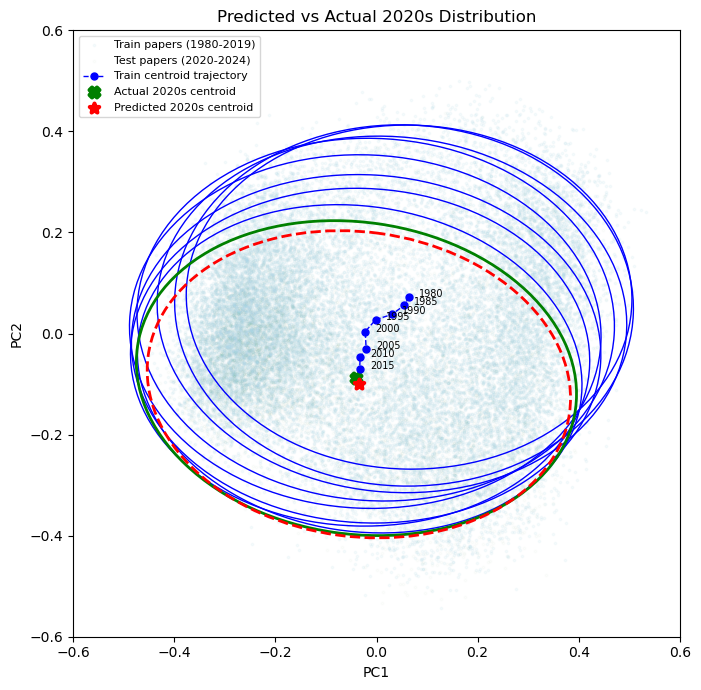

In [52]:
# =========================================================
# 8. visualization
# =========================================================

fig, ax = plt.subplots(figsize=(7, 7))

# train papers
ax.scatter(
    train_proj["PC1"],
    train_proj["PC2"],
    s=3,
    alpha=0.1,
    label="Train papers (1980-2019)",
    color="lightblue",
)

# actual test papers
ax.scatter(
    test_proj["PC1"],
    test_proj["PC2"],
    s=4,
    alpha=0.01,
    label="Test papers (2020-2024)",
    color="green",
)

# train bin centroids + ellipses
ax.plot(
    train_summary["centroid_PC1"],
    train_summary["centroid_PC2"],
    marker="o",
    linestyle="--",
    linewidth=1,
    markersize=5,
    label="Train centroid trajectory",
    color="blue",
)

for _, row in train_summary.iterrows():
    mean = [row["centroid_PC1"], row["centroid_PC2"]]
    cov = np.array(
        [[row["var_PC1"], row["cov_PC1_PC2"]], [row["cov_PC1_PC2"], row["var_PC2"]]]
    )
    plot_cov_ellipse(ax, mean, cov, n_std=2.0, linewidth=1, color="blue")
    ax.text(
        mean[0] + 0.02, mean[1], str(int(row["year_bin_v2"])), fontsize=7, color="black"
    )

# actual 2020s centroid + ellipse
ax.scatter(
    actual_mean[0],
    actual_mean[1],
    s=50,
    marker="X",
    label="Actual 2020s centroid",
    color="green",
    linewidth=3,
)
plot_cov_ellipse(ax, actual_mean, actual_cov, n_std=2.0, linewidth=2, color="green")

# predicted 2020s centroid + ellipse
ax.scatter(
    pred_mean[0],
    pred_mean[1],
    s=50,
    marker="*",
    label="Predicted 2020s centroid",
    color="red",
    linewidth=3,
)
plot_cov_ellipse(
    ax, pred_mean, pred_cov, n_std=2.0, linewidth=2, linestyle="--", color="red"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Predicted vs Actual 2020s Distribution")
ax.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

# save image
plt.savefig("./figures/Fig4_A.png", dpi=150, bbox_inches="tight")

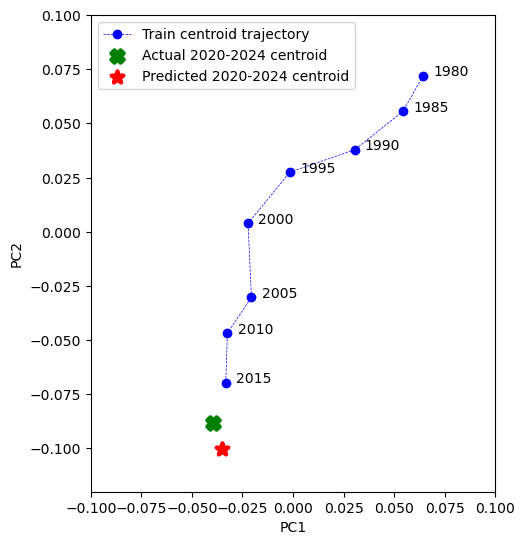

In [55]:
# =========================================================
# 8. visualization
# =========================================================

fig, ax = plt.subplots(figsize=(5.5, 5.5))


# train bin centroids + ellipses
ax.plot(
    train_summary["centroid_PC1"],
    train_summary["centroid_PC2"],
    marker="o",
    linestyle="--",
    linewidth=0.5,
    label="Train centroid trajectory",
    color="blue",
)

for _, row in train_summary.iterrows():
    mean = [row["centroid_PC1"], row["centroid_PC2"]]
    cov = np.array(
        [[row["var_PC1"], row["cov_PC1_PC2"]], [row["cov_PC1_PC2"], row["var_PC2"]]]
    )
    # plot_cov_ellipse(ax, mean, cov, n_std=2.0, linewidth=1.5)
    ax.text(
        mean[0] + 0.005,
        mean[1],
        str(int(row["year_bin_v2"])),
        fontsize=10,
        color="black",
    )

# actual 2020+ centroid + ellipse
ax.scatter(
    actual_mean[0],
    actual_mean[1],
    s=80,
    marker="X",
    label="Actual 2020-2024 centroid",
    color="green",
    linewidth=3,
)
# plot_cov_ellipse(ax, actual_mean, actual_cov, n_std=2.0, linewidth=3, color="green")

# predicted 2020s centroid + ellipse
ax.scatter(
    pred_mean[0],
    pred_mean[1],
    s=80,
    marker="*",
    label="Predicted 2020-2024 centroid",
    color="red",
    linewidth=3,
)
# plot_cov_ellipse(
#     ax, pred_mean, pred_cov, n_std=2.0, linewidth=3, linestyle="--", color="red"
# )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
# ax.set_title("Predicted vs Actual Centroid")
plt.legend(loc="upper left")
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xlim(-0.1, 0.1)
plt.ylim(-0.12, 0.1)

# save image
plt.savefig("./figures/Fig4_B.png", dpi=150, bbox_inches="tight")

# Future Prediction for 2025~

In [56]:
test_summary["x_bin_label"] = test_summary["year_bin"]
test_summary["x_bin"] = test_summary["year_bin"].apply(lambda x: int(x.split("-")[0]))
test_summary["year_bin_v2"] = test_summary["year_bin"].apply(
    lambda x: int(x.split("-")[0])
)
test_summary.head()

,year_bin,centroid_PC1,centroid_PC2,var_PC1,var_PC2,cov_PC1_PC2,n_papers,x_bin_label,x_bin,year_bin_v2
0,2020-2024,-0.03966,-0.088255,0.047328,0.024276,-0.003413,3829,2020-2024,2020,2020


In [57]:
whole_summary = pd.concat([train_summary, test_summary], ignore_index=True)
whole_summary.tail()

,year_bin,centroid_PC1,centroid_PC2,var_PC1,var_PC2,cov_PC1_PC2,n_papers,x_bin_label,x_bin,year_bin_v2
4,2000-2004,-0.022237,0.003858,0.054324,0.030612,-0.001096,3323,2000-2004,2000,2000
5,2005-2009,-0.020550,-0.030261,0.053841,0.029719,-0.001437,3263,2005-2009,2005,2005
6,2010-2014,-0.032429,-0.046830,0.051512,0.027929,-0.000736,3600,2010-2014,2010,2010
7,2015-2019,-0.033270,-0.069823,0.048287,0.026375,-0.003516,3697,2015-2019,2015,2015
8,2020-2024,-0.039660,-0.088255,0.047328,0.024276,-0.003413,3829,2020-2024,2020,2020


In [58]:
# =========================================================
# 4. fit trend models for centroid (use previous train + test together)
# =========================================================
x_bin = whole_summary["x_bin"].values.reshape(-1, 1)

# Polynomial
poly_degree = 2
model_pc1 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, whole_summary["centroid_PC1"])
model_pc2 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, whole_summary["centroid_PC2"])

# 2025s prediction point
future_bin_2025 = np.array([[2025]])

pred_mean_2025 = np.array(
    [model_pc1.predict(future_bin_2025)[0], model_pc2.predict(future_bin_2025)[0]]
)


# =========================================================
# 5. fit trend models for spread (covariance terms)
# =========================================================

# Polynomial
model_var1 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, whole_summary["var_PC1"])
model_var2 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, whole_summary["var_PC2"])
model_cov12 = make_pipeline(
    PolynomialFeatures(degree=poly_degree), LinearRegression()
).fit(x_bin, whole_summary["cov_PC1_PC2"])


pred_var1_2025 = max(model_var1.predict(future_bin_2025)[0], 1e-6)
pred_var2_2025 = max(model_var2.predict(future_bin_2025)[0], 1e-6)
pred_cov12_2025 = model_cov12.predict(future_bin_2025)[0]
pred_cov_2025 = np.array(
    [[pred_var1_2025, pred_cov12_2025], [pred_cov12_2025, pred_var2_2025]]
)
pred_cov_2025 = regularize_cov(pred_cov_2025)

print("\nPredicted 2025 centroid:")
print(pred_mean)

print("\nPredicted 2025 covariance:")
print(pred_cov_2025)


Predicted 2025 centroid:
[-0.03492404 -0.10043843]

Predicted 2025 covariance:
[[ 0.04178582 -0.00391018]
 [-0.00391018  0.02082024]]


(-0.6, 0.6)

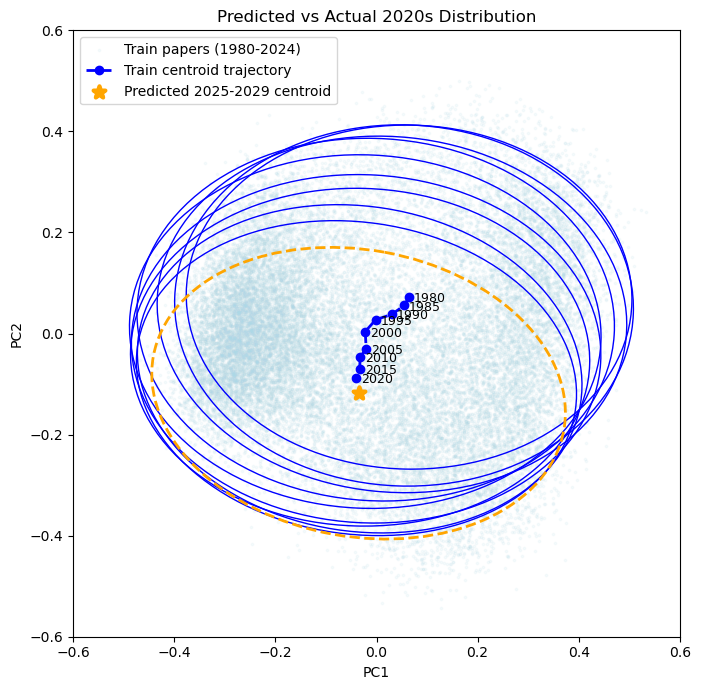

In [ ]:
whole_proj = pd.concat([train_proj, test_proj], ignore_index=True)
whole_proj.tail()

# =========================================================
# 8. visualization
# =========================================================

fig, ax = plt.subplots(figsize=(7, 7))

# train papers
ax.scatter(
    whole_proj["PC1"],
    whole_proj["PC2"],
    s=3,
    alpha=0.1,
    label="Train papers (1980-2024)",
    color="lightblue",
)


# train bin centroids + ellipses
ax.plot(
    whole_summary["centroid_PC1"],
    whole_summary["centroid_PC2"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Train centroid trajectory",
    color="blue",
)

for _, row in whole_summary.iterrows():
    mean = [row["centroid_PC1"], row["centroid_PC2"]]
    cov = np.array(
        [[row["var_PC1"], row["cov_PC1_PC2"]], [row["cov_PC1_PC2"], row["var_PC2"]]]
    )
    plot_cov_ellipse(ax, mean, cov, n_std=2.0, linewidth=1, color="blue")
    ax.text(
        mean[0] + 0.01,
        mean[1] - 0.01,
        str(int(row["year_bin_v2"])),
        fontsize=9,
        color="black",
    )


# predicted 2025s centroid + ellipse
ax.scatter(
    pred_mean_2025[0],
    pred_mean_2025[1],
    s=80,
    marker="*",
    label="Predicted 2025-2029 centroid",
    color="orange",
    linewidth=3,
)
plot_cov_ellipse(
    ax,
    pred_mean_2025,
    pred_cov_2025,
    n_std=2.0,
    linewidth=2,
    linestyle="--",
    color="orange",
)


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Predicted vs Actual 2020s Distribution")
ax.legend()
plt.tight_layout()
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

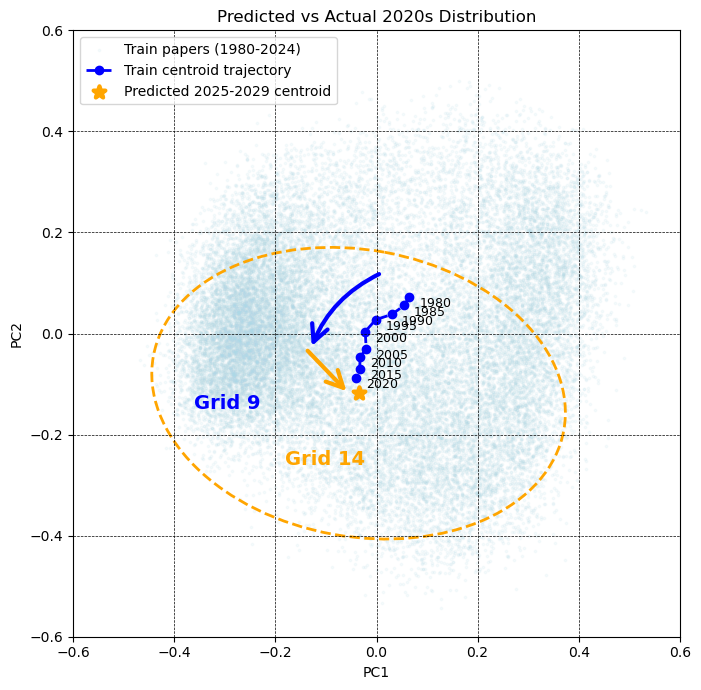

In [ ]:
# =========================================================
# 8. visualization
# =========================================================

fig, ax = plt.subplots(figsize=(7, 7))

# train papers
ax.scatter(
    whole_proj["PC1"],
    whole_proj["PC2"],
    s=3,
    alpha=0.1,
    label="Train papers (1980-2024)",
    color="lightblue",
)


# train bin centroids + ellipses
ax.plot(
    whole_summary["centroid_PC1"],
    whole_summary["centroid_PC2"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Train centroid trajectory",
    color="blue",
)

for _, row in whole_summary.iterrows():
    mean = [row["centroid_PC1"], row["centroid_PC2"]]
    cov = np.array(
        [[row["var_PC1"], row["cov_PC1_PC2"]], [row["cov_PC1_PC2"], row["var_PC2"]]]
    )
    # plot_cov_ellipse(ax, mean, cov, n_std=2.0, linewidth=1, color="blue")
    ax.text(
        mean[0] + 0.02,
        mean[1] - 0.02,
        str(int(row["year_bin_v2"])),
        fontsize=9,
        color="black",
    )

# predicted 2025s centroid + ellipse
ax.scatter(
    pred_mean_2025[0],
    pred_mean_2025[1],
    s=80,
    marker="*",
    label="Predicted 2025-2029 centroid",
    color="orange",
    linewidth=3,
)
plot_cov_ellipse(
    ax,
    pred_mean_2025,
    pred_cov_2025,
    n_std=2.0,
    linewidth=2,
    linestyle="--",
    color="orange",
)


# -------- arrows --------
ax.annotate(
    "",
    xy=(-0.13, -0.03),
    xytext=(0.01, 0.12),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=3,
        mutation_scale=30,
        connectionstyle="arc3,rad=0.2",
    ),
)

ax.annotate(
    "",
    xy=(pred_mean_2025[0] - 0.02, pred_mean_2025[1]),
    xytext=(-0.14, -0.03),
    arrowprops=dict(
        arrowstyle="->",
        color="orange",
        lw=3,
        mutation_scale=30,
        # connectionstyle="arc3,rad=-0.3",
    ),
)


ax.text(
    -0.36,
    -0.15,
    "Grid 9",
    color="blue",
    fontsize=14,
    fontweight="bold",
)

ax.text(
    -0.18,
    -0.26,
    "Grid 14",
    color="orange",
    fontsize=14,
    fontweight="bold",
)
# ------------------------


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Predicted vs Actual 2020s Distribution")
ax.legend()
plt.tight_layout()
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)

for y in [-0.6, -0.4, -0.2, 0, 0.2, 0.4]:
    plt.axhline(y, color="black", lw=0.5, ls="--")
for x in [-0.4, -0.2, 0, 0.2, 0.4]:
    plt.axvline(x, color="black", lw=0.5, ls="--")


# save image
plt.savefig("./figures/Fig5_A.png", dpi=150, bbox_inches="tight")

# Grid 14

In [62]:
# Increasing grid.
target = "Grid_14"
train_proj_target = train_proj.loc[train_proj.grid_bin == target, :]
print(train_proj_target.shape)
train_proj_target.head()

(763, 18)


,PMID,year,ASJC_1st,text,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,year_bin,x_bin,y_bin,grid_bin
230,6929006,1980,Oncology,Multistage models and primary prevention of ca...,-0.116478,-0.211299,0.219242,0.089992,0.075220,0.110815,-0.071500,-0.176815,0.358186,-0.003537,1980-1984,B,D,Grid_14
238,6451282,1980,Cancer Research,Effects of adjuvant chemohormonal therapy on t...,-0.080738,-0.201760,0.072217,0.024121,0.346386,0.099154,-0.319881,0.274722,-0.052152,0.057622,1980-1984,B,D,Grid_14
478,6271814,1981,Pharmacology (medical),Physiologic observations in a controlled clini...,-0.038762,-0.275709,-0.182398,0.022298,0.122342,0.098945,-0.018423,0.102763,0.153010,-0.064357,1980-1984,B,D,Grid_14
486,7333703,1981,Cancer Research,Dietary factors and breast cancer risk. | As p...,-0.039041,-0.239717,0.312954,0.296825,0.201509,0.109347,-0.037898,-0.142062,0.113884,-0.102669,1980-1984,B,D,Grid_14
571,6940657,1981,Cancer Research,Intermittent continuous iv infusion of high-do...,-0.016395,-0.221974,-0.289708,-0.002723,0.003292,-0.355333,-0.098097,0.317160,0.155676,0.102840,1980-1984,B,D,Grid_14


In [63]:
embedding_model = SentenceTransformer("neuml/pubmedbert-base-embeddings")
umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
vectorizer_model = CountVectorizer(stop_words="english")  # 불용어 제거
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


topic_model = BERTopic(
    embedding_model=embedding_model,  # 텍스트 벡터화
    # umap_model=pca_model,  # 차원 축소
    umap_model=umap_model,  # 차원 축소
    hdbscan_model=hdbscan_model,  # 클러스터링
    vectorizer_model=vectorizer_model,  # 단어 토큰화
    ctfidf_model=ctfidf_model,  # 주제 핵심 단어 추출
    nr_topics="auto",  # 너무 많은 주제가 나오면 자동으로 병합
)

In [64]:
input_docs = train_proj_target.text.tolist()
input_year = train_proj_target.year.tolist()
topics, probs = topic_model.fit_transform(input_docs)

In [65]:
# (OPTIONAL): I don't think it helps interpretability, it rather makes keywords more blurry. --> NOT using this.

# Reduce outliers using the c-tf-idf strategy
# new_topics = topic_model.reduce_outliers(input_docs, topics, strategy="c-tf-idf")
# topic_model.update_topics(
#     input_docs, topics=new_topics, vectorizer_model=vectorizer_model
# )

In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(10).to_markdown())

|    |   Topic |   Count | Name                                   | Representation                                                                                                | Representative_Docs                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
# Keyword bar chart
fig_words = topic_model.visualize_barchart(
    top_n_topics=8, n_words=10, height=300, title="Grid 9: Key Topic Words"
)
fig_words.show()

In [75]:
# Time-based topic analysis
topics_over_time = topic_model.topics_over_time(input_docs, input_year)
topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=8,
    normalize_frequency=True,
    width=800,
    height=400,
    title="Grid 14: Keywords over Time",
)